/tmp/ipykernel_4251/2052501518.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


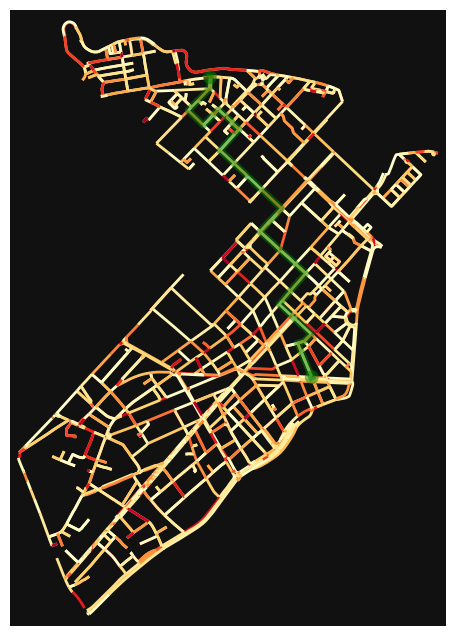

In [29]:
import osmnx as ox
import networkx as nx
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type="drive")

for u, v, k, data in G.edges(keys=True, data=True):
    traffic_volume = random.random()
    current_speed = random.uniform(5, 50)
    risk_index = (traffic_volume * (50 - current_speed) / 50)
    data['risk'] = risk_index

edge_values = [data['risk'] for u, v, k, data in G.edges(keys=True, data=True)]
norm = colors.Normalize(vmin=min(edge_values), vmax=max(edge_values))
cmap = cm.get_cmap('YlOrRd')
edge_colors = [cmap(norm(val)) for val in edge_values]

fig, ax = ox.plot_graph(G, edge_color=edge_colors, edge_linewidth=2, node_size=0, show=False, close=False)
orig = list(G.nodes)[0]
dest = list(G.nodes)[50]
alt_route = nx.shortest_path(G, orig, dest, weight='risk')
ox.plot_graph_route(G, alt_route, route_color='g', route_linewidth=5, node_size=0, ax=ax)
plt.show()
